In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

import shap

# fname = '/home/server/Projects/data/AKI/results/shap_combined_gpu_10000.pkl'
# fname = '/home/server/Projects/data/AKI/results/shap_tabular_combined.pkl'
fname = '/home/server/Projects/data/AKI/results/shap_combined.pkl'
fname_x800 = '/home/server/Projects/data/AKI/results/shap_combined_x800.pkl'


with open(fname, 'rb') as file:
    shap_values = pickle.load(file)

with open(fname_x800, 'rb') as file:
    X800 = pickle.load(file)

N_samples = shap_values.values.shape[0]

file = '/home/server/Projects/data/AKI/tabular_combined.csv'
y = pd.read_csv(file).pop('aki_boolean')
y = y[:N_samples]

In [2]:
def denormalize(shap_values):
    norm_csv = '/home/server/Projects/data/base/normalization_stats.csv'
    df_stats = pd.read_csv(norm_csv)

    df_stats = df_stats.set_index('Unnamed: 0')
    if 'std' not in df_stats.columns:
        df_stats['std'] = np.sqrt(df_stats['var'])

    features_to_unnormalize = list(set(df_stats.index) & set(shap_values.feature_names))
    feature_indices = [shap_values.feature_names.index(f) for f in features_to_unnormalize]

    data_unnorm = shap_values.data.copy()

    for i, feature in zip(feature_indices, features_to_unnormalize):
        mean = df_stats.loc[feature, 'mean']
        std = df_stats.loc[feature, 'std']
        data_unnorm[:, i] = data_unnorm[:, i] * std + mean
    return shap.Explanation(
            values=shap_values.values,
            base_values=shap_values.base_values,
            data=data_unnorm,
            feature_names=shap_values.feature_names
        )

In [3]:
shap_values = denormalize(shap_values)

In [ ]:
# negative waterfalls
np.random.seed(42)
random_ints = np.random.randint(shap_values.shape[0], size=20)
for i in random_ints:
    if not y[i]:
        shap.plots.waterfall(shap_values[i], max_display=20)

In [ ]:
# positive waterfalls

np.random.seed(42)
random_ints = np.random.randint(shap_values.shape[0], size=13 * 20)
for i in random_ints:
    if y[i]:
        shap.plots.waterfall(shap_values[i], max_display=20)

In [5]:
def scatter(shap_values, feature_name, y, fit_type='linear'):
    feature_index = list(shap_values.feature_names).index(feature_name)
    shap_vals = shap_values.values[:, feature_index]
    feature_vals = shap_values.data[:, feature_index]

    plt.scatter(feature_vals[y], shap_vals[y], s=3, zorder=3, color='r', label='AKI Positive')
    plt.scatter(feature_vals[~y], shap_vals[~y], s=3, zorder=3, color='b', label='AKI Negative')

    min_x = min(feature_vals)
    max_x = max(feature_vals)
    trend_x = np.linspace(min_x, max_x, 100)
    mask = y
    if fit_type == 'linear':
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(feature_vals[mask], shap_vals[mask])
        trendline = slope * trend_x + intercept
        x_intercept = -1 * intercept / slope
        label=f'Trendline, intercept at x = {x_intercept:0.02f}'
    elif fit_type == 'quadratic':
        from numpy.polynomial.polynomial import Polynomial
        coeffs = np.polyfit(feature_vals[mask], shap_vals[mask], 2)
        trendline = np.polyval(coeffs, trend_x)
        a, b, c = coeffs
        # Quadratic x-intercepts (if any)
        discriminant = b**2 - 4*a*c
        if discriminant >= 0:
            roots = np.roots(coeffs)
            x_intercept = ', '.join(f'{r:.2f}' for r in roots)
        else:
            x_intercept = 'None'
        label = f'Quadratic trend, x-intercept(s): {x_intercept}'
    elif fit_type == 'negative_gaussian':
        from scipy.optimize import curve_fit
        def exp_func(x, a, b, c, d):
            return -a * np.exp(-1 * b * (x - c)**2) + d
        
        bounds = (
            [0,    0,   min_x, -np.inf],  # Lower bounds (a > 0, b > 0)
            [np.inf, np.inf,  max_x,  np.inf]  # Upper bounds
        )

        popt, _ = curve_fit(exp_func, feature_vals[mask], shap_vals[mask], maxfev=10000, bounds=bounds)
        a, b, c, d = popt
        trendline = exp_func(trend_x, *popt)

        try:
            if d / a > 0 and (-1 / b) * np.log(d / a) >= 0:
                x_intercept = c + (-1 / b) * np.log(d / a)
                label = f'Exponential trend, intercept at x = {x_intercept:.2f}'
            else:
                x_intercept = None
                label = f'Exponential trend, no real x-intercept'
        except Exception as e:
            x_intercept = None
            label = f'Exponential trend, intercept undefined'
    elif fit_type == 'exponential':
        from scipy.optimize import curve_fit
        def exp_func(x, a, b, c):
            return a * np.exp(-1 * b * x) + c

        popt, _ = curve_fit(exp_func, feature_vals[mask], shap_vals[mask], maxfev=10000)
        a, b, c = popt
        trendline = exp_func(trend_x, *popt)

        try:
            if -c / a > 0:
                x_intercept = (-1 / b) * np.log(-c / a)
                label = f'Exponential trend, intercept at x = {x_intercept:.2f}'
            else:
                x_intercept = None
                label = f'Exponential trend, no real x-intercept'
        except Exception as e:
            x_intercept = None
            label = f'Exponential trend, intercept undefined'


    plt.plot(trend_x, trendline, color='black', label=label, lw=2, zorder=5)

    # trendline for only aki positive cases
    # slope, intercept, r_value, p_value, std_err = linregress(feature_vals[y[:10000]], shap_vals[y[:10000]])
    # trend_x = np.linspace(min(feature_vals), max(feature_vals), 100)
    # trendline = slope * trend_x + intercept
    # plt.plot(trend_x, trendline, color='orange', label='Trendline', lw=2, zorder=5)

    plt.grid(True, linewidth=0.2, zorder=0)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.xlabel(feature_name)
    plt.ylabel('Shap value for ' + feature_name)
    plt.show()


In [ ]:
# prototyping scatter
feature_names = ['mean_etco2', 'mean_art_sbp', 'mean_art_mbp']
for feature_name in feature_names:
    scatter(shap_values, feature_name, y, fit_type='negative_gaussian')

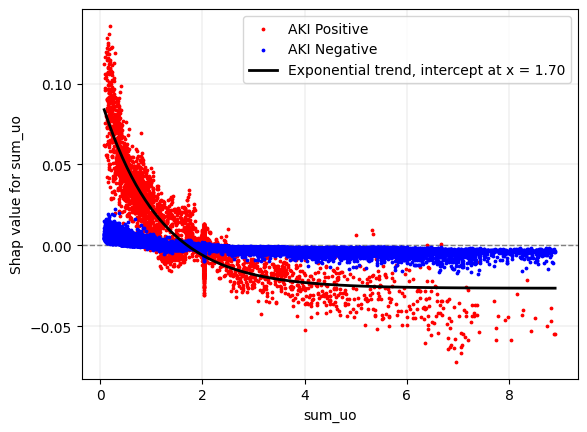

In [26]:
# prototyping scatter
feature_name = 'sum_uo'
scatter(shap_values, feature_name, y, fit_type='exponential')

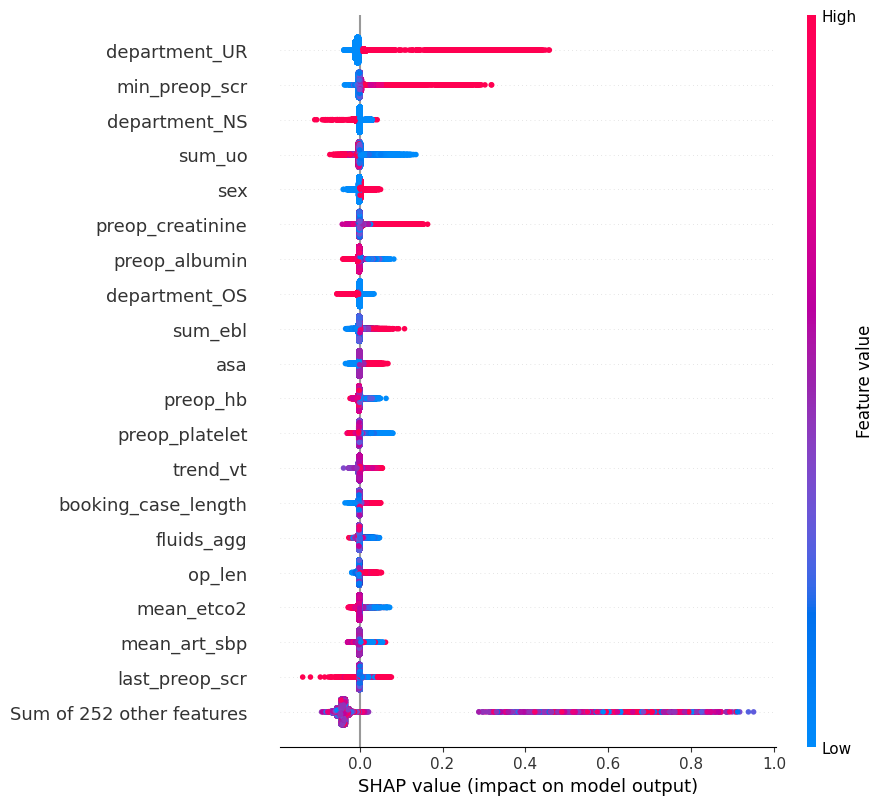

In [ ]:
# 20 beeswarm
shap.plots.beeswarm(shap_values, max_display=20)

In [ ]:
# full beeswarm
shap.plots.beeswarm(shap_values, max_display=shap_values.shape[1])

In [ ]:
# cross scatters auto gen
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:20]
top_features = [shap_values.feature_names[i] for i in top_indices]
for feature_1 in top_features:
    shap.plots.scatter(shap_values[:, feature_1], 
                    color=shap_values)

In [ ]:
# cross scatters
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:10]
top_features = [shap_values.feature_names[i] for i in top_indices]
for feature_1 in top_features:
    for feature_2 in top_features:
        if feature_1 != feature_2:
            shap.plots.scatter(shap_values[:, feature_1], 
                           color=shap_values[:, feature_2])

In [ ]:
# scatters
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:30]
top_features = [shap_values.feature_names[i] for i in top_indices]

for feature in top_features:
    scatter(shap_values, feature, y)

In [6]:
shap_values.values.shape, shap_values.data.shape, shap_values.base_values.shape

((10000, 271), (10000, 271), (10000,))

In [7]:
def average_positive_shap(shap_values, y_pred):
    return shap.Explanation(
        values=shap_values.values[y_pred].mean(axis=0, keepdims=True),
        data=shap_values.data[y_pred].mean(axis=0, keepdims=True),
        base_values=shap_values.base_values[y_pred].mean(axis=0, keepdims=True),
        feature_names=shap_values.feature_names
    )

In [8]:
def consolidate_engineered_features(shap_values):
    all_features = shap_values.feature_names

    shapdic = {}
    for feature in all_features:
        shapdic[feature] = shap_values[:, feature].values

    # cut down on all the repeat columns from taking eight metrics for each of these regular variables
    repeated_metrics = ["rr", "hr", "spo2", "fio2", "pmean", "etco2", "peep", 
    "pip", "art_mbp", "cpat", "vt", "art_sbp", "art_dbp", 
    "minvol", "pplat", "bt", "etgas", "cvp", "pap_mbp", "pap_sbp", 
    "pap_dbp", "nibp_mbp", "nibp_dbp", "nibp_sbp", 'department']

    for metric in repeated_metrics:
        features = [f for f in all_features if metric in f]
        if features:
            total = sum([shapdic.pop(label) for label in features])
            shapdic[metric] = total

    consolidated_feature_names = list(shapdic.keys())
    consolidated_values = np.column_stack([shapdic[key] for key in consolidated_feature_names]) 

    return shap.Explanation(
        values=consolidated_values,
        data=shap_values.data,
        base_values=shap_values.base_values,
        feature_names=consolidated_feature_names
    )

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def sudobee(shap_values, y_pred, N_show = 20):
    avg_shap_values = shap.Explanation(
        values=np.abs(shap_values.values).mean(axis=0, keepdims=True),
        data=shap_values.data.mean(axis=0, keepdims=True),
        base_values=shap_values.base_values.mean(axis=0, keepdims=True),
        feature_names=shap_values.feature_names
    )
    pos_shap_values = average_positive_shap(shap_values, y_pred)
    sorted_indices = np.argsort(np.abs(pos_shap_values.values[0]))[::-1]


    # Example data
    words = pos_shap_values[:,sorted_indices].feature_names[:N_show]
    left_values = pos_shap_values[:,sorted_indices].values[0][:N_show]
    right_values = avg_shap_values[:,sorted_indices].values[0][:N_show]

    # Plot setup
    y_pos = np.arange(len(words))
    height = 0.4

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars
    ax.barh(y_pos, left_values, height=height, color='salmon', align='center', label='AKI-Positive')
    ax.barh(y_pos, right_values, height=height, left=0, color='skyblue', align='center', label='Average Magnitude')

    # Draw center line
    ax.axvline(0, color='gray', linewidth=1)

    # Label settings
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()  # Optional: largest at top
    ax.set_ylabel('Feature')
    ax.set_xlabel('Shap Value')
    ax.set_title('Top Shap Contributing Variables')
    ax.legend()

    plt.tight_layout()
    plt.show()



In [17]:
con_shap_values = consolidate_engineered_features(shap_values)

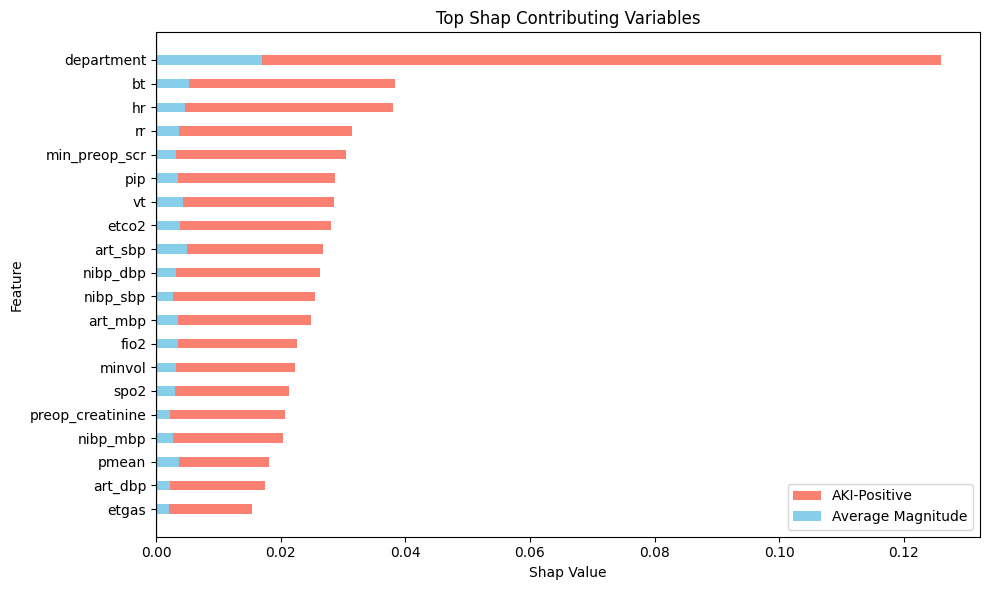

In [19]:
sudobee(con_shap_values, y)

In [ ]:
# negative average waterfall
shap_value_avg_neg = average_positive_shap(con_shap_values, y)
shap.plots.waterfall(shap_value_avg_neg[0], max_display=20)

In [ ]:
# full negative waterfall
shap.plots.waterfall(shap_value_avg_neg[0], max_display=shap_value_avg_neg.shape[1])